<div style="background:#4E3629;color:#fff;padding:20px 24px;border-radius:8px;font-family:Lato,Arial,Helvetica,sans-serif;"><div style="color:#E9C9C9;font-size:13px;letter-spacing:1.5px;font-weight:bold;">SUMMER@BROWN 2026 &middot; INTRODUCTION TO DATA SCIENCE</div><div style="font-size:27px;font-weight:bold;margin-top:6px;">Assignment 1.3 &mdash; Who Should the Bank Call?</div><div style="font-size:15px;margin-top:6px;color:#f1eae5;">Logistic Regression &middot; Your First Team Project &middot; Python</div><div style="height:4px;background:#990000;margin-top:14px;border-radius:2px;"></div></div>

## The mission
Your team is the new **data science unit at a Portuguese bank**. The bank sells **term deposits** through **phone-call campaigns** — but the call centre **can’t phone everyone**. Using data from past campaigns (45,211 contacts), you’ll build a **logistic regression** model that estimates each client’s *probability* of subscribing, then rank clients so the bank calls the **most promising first**.

The target `y` is binary (subscribed = yes/no), which is exactly what logistic regression is for: it returns a probability between 0 and 1.

<div style="border-left:6px solid #990000;background:#FAF4EC;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#990000;">How this builds on Assignments 1.1 and 1.2</b><br>You already have every tool — this connects them:<ul style="margin:8px 0 0 0;"><li><b>1.2 → missing data:</b> last time you <i>dropped</i> rows; here you’ll <i>impute</i> — and first uncover values hidden as "unknown".</li><li><b>1.2 → hypothesis testing:</b> a t-test on numbers becomes a <b>chi-square test</b> on categories.</li><li><b>1.2 → regression:</b> linear regression predicted a <i>number</i>; logistic regression predicts a <i>probability</i>.</li><li><b>1.2 → train/test &amp; “don’t peek”:</b> the split returns, plus scaling fit on the training set only.</li><li><b>1.1 → storytelling:</b> you’ll finish with a one-paragraph recommendation for the bank.</li></ul></div>

## Working as a team: Colab + GitHub
This is your **first team project**, and collaboration is graded. Use **Google Colab** to write and run code together in real time, and **GitHub** for version control and submission. Edit together in Colab during live sessions; at each milestone use **File → Save a copy in GitHub** to commit, *early and often*.

**Why notebooks fight git:** an `.ipynb` is JSON, so if two people edit the *same cell* and both push you get an ugly merge conflict. Avoid it: one **driver** types during live sessions, each member **owns specific sections**, and **pull before / commit after** you work.

**You’re an international cohort** — coordinating across **time zones** is real. Agree on meeting times *in everyone’s local time* and record them in the charter.

### ✉ Team Charter (fill in before coding)

| Field | Your team’s entry |
|---|---|
| Team number | |
| Members (name — **time zone**) | |
| Section owners | |
| Synchronous meeting times (**each member’s local time**) | |
| Async channel + expected response time | |
| How you’ll avoid notebook merge conflicts | |

**Suggested roles** (everyone writes code *and* answers red questions):
**Data Wrangler** (Sec 1–3) ·
**Analyst** (Sec 4 + 6) ·
**Modeler** (Sec 5 & 7) ·
**Evaluator** (Sec 8–9) ·
**PM / Storyteller** (framing, Sec 10, ReadMe + charter).

## The dataset & what every column means
The file is **`bank-full.csv`** (45,211 rows). **It is semicolon-separated** — read it with `sep=';'`. Here is what each variable means:

| Variable | Meaning | Type |
|---|---|---|
| `age` | Client’s age, in years | numeric |
| `job` | Type of job (admin., technician, management, …) | categorical |
| `marital` | Marital status (married / single / divorced) | categorical |
| `education` | Education level (primary / secondary / tertiary) | categorical |
| `default` | Has credit in default? | yes / no |
| `balance` | Average yearly balance, in euros (can be negative) | numeric |
| `housing` | Has a housing loan? | yes / no |
| `loan` | Has a personal loan? | yes / no |
| `contact` | How the client was contacted (cellular / telephone) | categorical |
| `day` | Day of the month of the last contact | numeric |
| `month` | Month of the last contact (jan … dec) | categorical |
| `duration` | Last call duration, in seconds | numeric — **⚠️ drop it (see below)** |
| `campaign` | # contacts during this campaign for this client | numeric |
| `pdays` | Days since the client was last contacted in a previous campaign | numeric (**−1 = never contacted**) |
| `previous` | # contacts before this campaign | numeric |
| `poutcome` | Outcome of the *previous* campaign (failure / other / success) | categorical |
| **`y`** | **TARGET — did the client subscribe to the term deposit?** | **yes / no** |

<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:12px 16px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Three things to know before you start</b><ul style="margin:8px 0 0 0;"><li><b>"unknown" means missing.</b> In <code>job</code>, <code>education</code>, <code>contact</code>, and <code>poutcome</code>, the value <code>"unknown"</code> is really a missing value in disguise — so you must surface it before you can impute (Section 3).</li><li><b>Drop <code>duration</code>.</b> It’s only known <i>after</i> a call ends, so it can’t help you decide whom to call — and it basically gives away the answer. Keeping it is <b>data leakage</b> (Section 5).</li><li><b><code>pdays = −1</code></b> is a code for “never previously contacted,” not a real day count.</li></ul></div>

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>

## Grading scheme (150 points)

| # | Section | Points |
|---|---|---|
| 1 | Importing libraries & loading data | 10 |
| 2 | Data exploration & descriptive stats | 10 |
| 3 | Surfacing & imputing missing values | 15 |
| 4 | Hypothesis test (chi-square) | 15 |
| 5 | Pre-processing (drop leakage, encode) | 15 |
| 6 | Data visualization | 10 |
| 7 | Model building (split, scale, fit) | 20 |
| 8 | Evaluation (confusion, baseline, ROC/AUC) | 15 |
| 9 | Campaign simulation (who to call) | 10 |
| 10 | Final recommendation (storytelling) | 5 |
| 11 | Red questions | 15 |
| 12 | Teamwork & process | 10 |
| | **Total** | **150** |

**Bonus (up to +10):** +5 for beating the majority-class baseline on **AUC** (not raw accuracy); +5 for an optional Random Forest leaderboard entry.

**How to read this notebook:** markdown intros open each section; <span style="color:#990000"><b>red questions</b></span> are answered in your own words in the cell provided; **`# <Your code here>`** marks where you write code. “Expected output” notes describe the *shape* of the result — match the idea, not every digit.

## 1) Importing libraries

The starter cell imports far more than this notebook needs. **Delete every import you don’t actually use.**

In [ ]:
# KEEP ONLY THE LIBRARIES THIS NOTEBOOK ACTUALLY USES; DELETE THE REST.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time
from collections import Counter
from scipy import stats
from scipy.stats import chi2_contingency
import scipy.optimize as opt
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

### <span style="color:#990000">Q1. Why keep only the libraries the notebook actually uses? Give at least two reasons.</span>

>The biggest reason why we should only keep the libraries the notebook actually uses is to keep our code concise and help it run faster. Some libraries, like sklearn, are so massive that they take too much time and processing power to import fully, which is why we use "from" to specify which functions we want to import from these huge libraries. This still applies here, just on a smaller scale. Overall, we want to avoid extra code to keep the notebook from getting cluttered while also saving on time and processing by not importing the libraries we don't need.

## 2) Importing the data & descriptive statistics

Load `bank-full.csv` — **remember it is semicolon-separated** — then confirm it imported correctly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# READ THE DATA  (the file is SEMICOLON-separated!)
# <Your code here>
data = pd.read_csv("/content/drive/MyDrive/bank-full.csv", sep=";") #save bank-full.csv to your google drive in Colab Notebooks folder

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
TARGET = "y"      # the column that records whether the client subscribed (yes/no)
print("Target column:", TARGET)
print(data.columns.tolist())

Target column: y
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [ ]:
# 1. DIMENSIONS
data.shape

(45211, 17)

In [ ]:
# 2. FIRST 15 ROWS
data.head(15)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [ ]:
# 3. LAST 5 ROWS
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [ ]:
# 4. DESCRIPTIVE STATISTICS
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## 3) Surfacing & imputing missing values

In **1.2** you *dropped* rows with missing data; here every row is a client the bank paid to contact, so we **impute** instead. But first a twist: this dataset hides its missing values as the text **`"unknown"`**. Surface them, *then* impute — mean for numeric, mode for categorical.

**Step 1 (given):** turn the hidden `"unknown"` values into real missing values so pandas can see them.

In [ ]:
# Surface the hidden missing values
data = data.replace("unknown", np.nan)

In [ ]:
# CHECK FOR MISSING VALUES (per column)
data.isna().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
# IMPUTE NUMERIC COLUMNS WITH THE MEAN
# no numeric columns with missing values

In [ ]:
# IMPUTE CATEGORICAL COLUMNS WITH THE MODE (not the target)
# editing all categorical columns with missing values, filling in with mode using [0] to impute with the mode and not return a series (fixed using built in Colab Gemini)
data["job"] = data["job"].fillna(data["job"].mode()[0])
data["education"] = data["education"].fillna(data["education"].mode()[0])
data["contact"] = data["contact"].fillna(data["contact"].mode()[0])
data["poutcome"] = data["poutcome"].fillna(data["poutcome"].mode()[0])

In [ ]:
# Confirm no missing values remain
print("missing values left:", int(data.isnull().sum().sum()))
data.head(10)

missing values left: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,cellular,5,may,261,1,-1,0,failure,no
1,44,technician,single,secondary,no,29,yes,no,cellular,5,may,151,1,-1,0,failure,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,cellular,5,may,76,1,-1,0,failure,no
3,47,blue-collar,married,secondary,no,1506,yes,no,cellular,5,may,92,1,-1,0,failure,no
4,33,blue-collar,single,secondary,no,1,no,no,cellular,5,may,198,1,-1,0,failure,no
5,35,management,married,tertiary,no,231,yes,no,cellular,5,may,139,1,-1,0,failure,no
6,28,management,single,tertiary,no,447,yes,yes,cellular,5,may,217,1,-1,0,failure,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,cellular,5,may,380,1,-1,0,failure,no
8,58,retired,married,primary,no,121,yes,no,cellular,5,may,50,1,-1,0,failure,no
9,43,technician,single,secondary,no,593,yes,no,cellular,5,may,55,1,-1,0,failure,no


### <span style="color:#990000">Q2. In 1.2 you <i>deleted</i> rows with missing data; here you <i>fill them in</i> — and the data even hid the gaps as "unknown". Why is imputing often better when every row is a client the bank doesn’t want to lose? When might imputing be a bad idea here?</span>

Imputing is oftentimes better because more of the data can be used without skewing the results. This means that instead of dropping the 36,959 rows containing missing values for the poutcome, we can instead impute and use the rest of the data in those rows to help build our model. This is especially true for this scenario, as there are a limited number of clients that the bank can actually contact, with each lost row becoming a missed opportunity to make the model more accurate. With that being said, if for example poutcome was the only factor we wanted to use in order to train our model, then imputing with the mode would in fact skew our model because there are so many rows with missing values for this variable. Overall, when there is other useful data for the other variables in the dataset that would be lost by deleting complete rows of missing data, we should consider imputing so as to train our model on as much data as possible.

### <span style="color:#990000">Q3. Why impute the <b>mean</b> for numeric columns but the <b>mode</b> for categorical columns?</span>

We imputed the mean for numeric columns because this provides a valid central statistic for us to replace missing values with, as the values in numeric columns will be centered around the mean. As for the categorical columns, we imputed with the mode because there is not a mean for a categorical variable, only the category that shows up the most within that column.

## 4) Hypothesis test (chi-square) — callback to 1.2

Test a hunch the way you did in 1.2, but for **categorical** data, using a **chi-square test of independence**: *is the outcome of the previous campaign (`poutcome`) associated with subscribing now?* Run it **before** encoding.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Define TARGET as it might not be defined if cells were run out of order
TARGET = "y"

# To ensure the chi-square test runs on the data *before* one-hot encoding,
# we reload and preprocess the data locally within this cell.
# This makes the cell independent of the global 'data' state after encoding.
original_data_for_test = pd.read_csv("/content/drive/MyDrive/bank-full.csv", sep=";")
original_data_for_test = original_data_for_test.replace("unknown", np.nan)

# Impute categorical columns with the mode, specifically for the relevant columns
for col in ["job", "education", "contact", "poutcome"]:
    if col in original_data_for_test.columns and original_data_for_test[col].dtype == "object":
        original_data_for_test[col] = original_data_for_test[col].fillna(original_data_for_test[col].mode()[0])

feature = "poutcome"     # try others too, e.g. "job" or "housing"

# 1. Contingency table: feature vs TARGET
table = pd.crosstab(original_data_for_test[feature], original_data_for_test[TARGET])
print(table)

# 2. Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(table)

# 3. Print the chi-square statistic and the p-value
print(f"\nchi-square = {chi2:.1f}   p-value = {p:.3e}   dof = {dof}")

y            no   yes
poutcome             
failure   37856  4004
other      1533   307
success     533   978

chi-square = 4341.7   p-value = 0.000e+00   dof = 2


### <span style="color:#990000">Q4. State H₀ and H₁ for this test. Based on the p-value, at the 0.05 level is `poutcome` associated with subscribing? What does that mean for the bank?</span>

> The H₀ null hypothesis is that no association between the previous campaign outcome poutcome and whether a customer subscribes, and the H₁ the alternative hypothesis there is an association between the previous campaign outcome poutcome and whether a customer subscribes y. Since the p-value is 0 and less than 0.05 we reject H₀ this means the outcome of a customer's previous campaign can help predict whether they are likely to subscribe.

## 5) Pre-processing: drop leakage, then encode

**Step 1 (given) — drop `duration`.** Call duration is only known *after* the call, so it can’t inform *whom to call*, and it all but reveals the outcome. Keeping it is **data leakage**.

In [ ]:
data = data.drop(columns=["duration"])

### <span style="color:#990000">Q5. Why must we drop `duration` for a model that decides <i>whom to call</i>? What kind of mistake is keeping it, and what would happen to our scores if we left it in?</span>

> We drop duration because the models purpose it to rank and choose clients before making any phone calls. At that point, the call duration is unknown so it cannot be used to make the decision. Keeping the duration column is a mistake called data leakage because it contains information about the future. By keeping it, we are giving the model information it would not actually have in the real world. If we left it in, the training scores would look perfect but when the model is used on real un called clients, the model will fail because it does not have any actual call lengths to read.
Source: https://www.ibm.com/think/topics/data-leakage-machine-learning

**Step 2 — encode.** Label-encode the **target** to a single 0/1 column; one-hot encode the categorical **features** only (don’t leak the target).

In [ ]:
# <Your code here>      # y_series = data[TARGET].map({"yes": 1, "no": 0})
#define targer variable name
TARGET = 'y'
# --- TARGET: make it a single 0/1 column (values are lowercase "yes"/"no") ---
y_series = data[TARGET].map({"yes": 1, "no": 0})

# --- FEATURES: one-hot encode categorical FEATURES only ---
features = data.drop(columns=[TARGET])
ohe = OneHotEncoder(sparse_output=False)   # current scikit-learn uses sparse_output (not sparse=)
data_transformed = pd.DataFrame(index=features.index)

for column in features.columns:
    if features[column].dtype == "object":
        # one-hot encode this categorical feature; name columns like column_value
        encoded_array = ohe.fit_transform(features[[column]])
        column_names = [f"{column}_{cat}" for cat in ohe.categories_[0]]
        data_transformed[column_names] = encoded_array
    else:





        # numeric column: copy across unchanged
        data_transformed[column] = features[column]


data_transformed[TARGET] = y_series.values
data = data_transformed
data.head(10)

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_nov,month_oct,month_sep,campaign,pdays,previous,poutcome_failure,poutcome_other,poutcome_success,y
0,58,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
1,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
2,33,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
3,47,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
4,33,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
5,35,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
6,28,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
7,42,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
8,58,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0
9,43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,-1,0,1.0,0.0,0.0,0


### <span style="color:#990000">Q6. Why one-hot encode the features but label-encode the target? What could go wrong if you one-hot encoded the target instead?</span>

We have to treat the features are the target differently because perform different jobs in the model. We one-hot encode the features because logistic regression requires each feature to be a single number. One hot enconding splits each feature into seperate yes/no columns so the model treats them as seperate equal choices. We label encode the targer because in logistic regression the model is designed to calculate a single probability score between 0 and 1. Label encoding get no to equal 0 and yes to equal 1. If we one-hot encoded the target it would split y into y_no and y_yes. Logistic regression though, is only built to predict one single column at a time. By giving it two seperate columns the math would break because model would not know what column it is supposed to be predicting.
Source: https://datascience.stackexchange.com/questions/9443/when-to-use-one-hot-encoding-vs-labelencoder-vs-dictvectorizor

## 6) Data visualization

Plot **histograms** of every column, then a correlation **heatmap**. *Expected output:* a grid of histograms and a coloured heatmap.

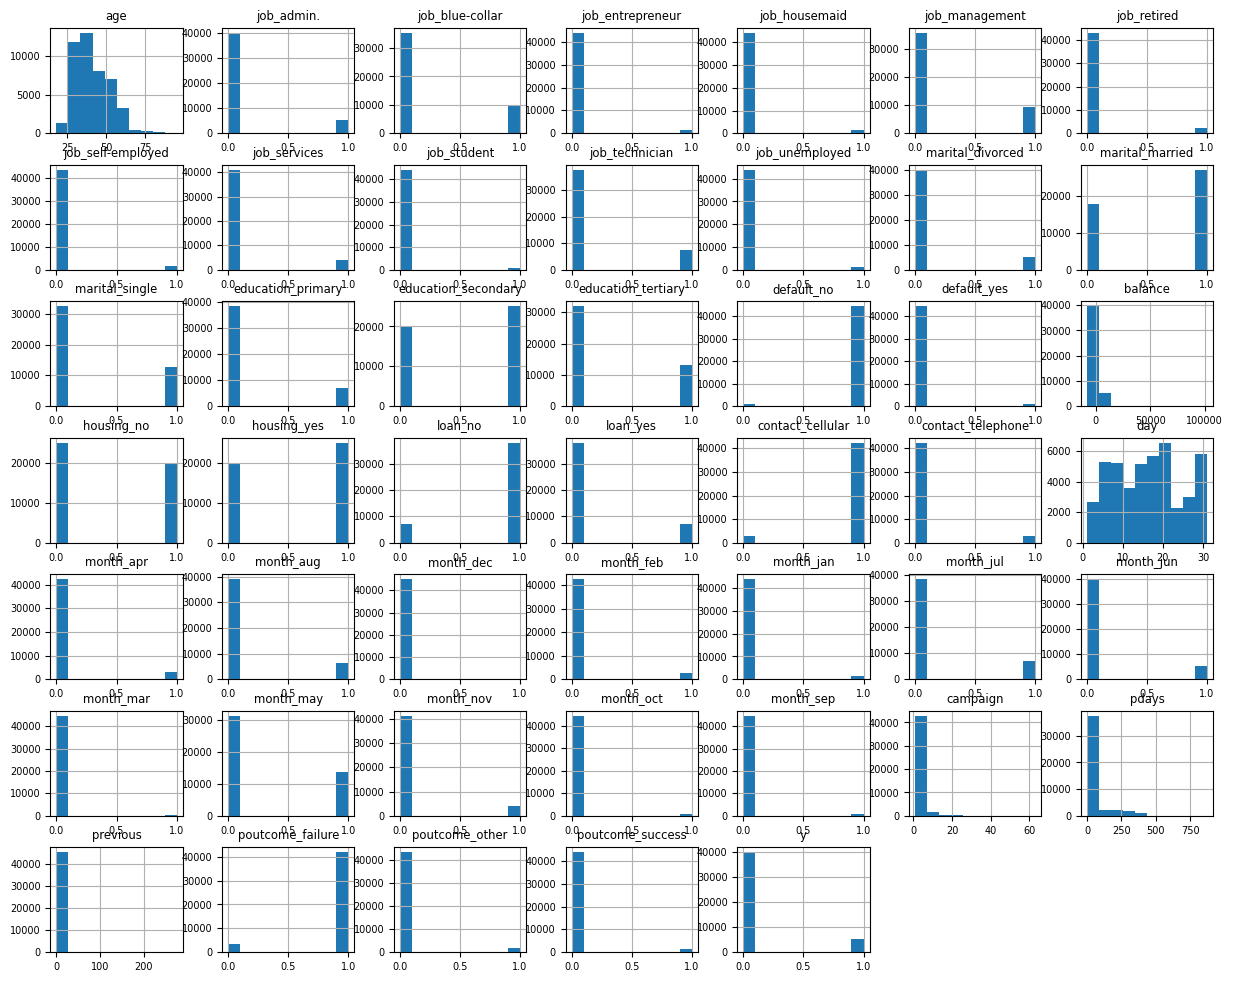

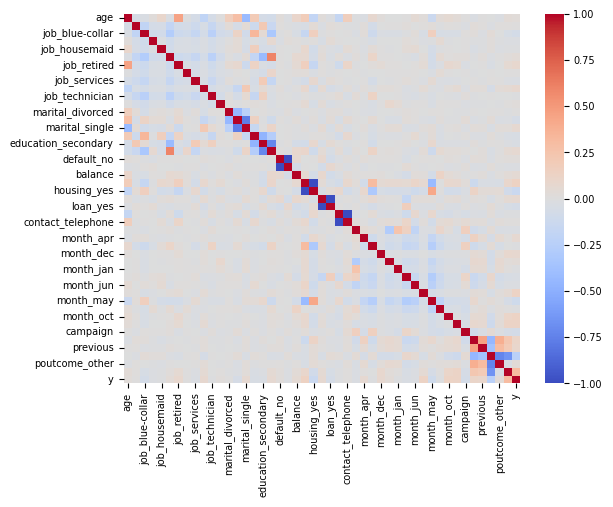

In [ ]:
# HISTOGRAMS
# <Your code here>
data.hist(figsize=(15, 12))
plt.show()

# CORRELATION MATRIX + HEATMAP
plt.rcParams["font.size"] = 7
# <Your code here>
corr = data.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.show()

### <span style="color:#990000">Q7. Describe the histograms — which features are skewed?</span>

Most features are categorical so it is either 0 or 1. For the continous features, age, pdays, balance, and campaign are skewed to the right. Days is more uniformly distributed, with no clear skewed pattern.


### <span style="color:#990000">Q8. What does the correlation heatmap reveal? Is any single feature strongly correlated with the target?</span>

Most features have weak correlations with the target y. No single feature is strongly correlated with y, suggesting that predicting whether a customer subscribes will depends on a combination of multiple features, not any one feature alone.

## 7) Model building

Recall from **1.2**: linear regression drew a line for a *number*; logistic regression bends it into an **S-curve** so the output is a probability in [0, 1].

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# --- Re-load data and apply preprocessing steps ---
# This section is added to ensure 'data' is defined and preprocessed correctly in this cell

# Load the data (from d88ac554)
data = pd.read_csv("/content/drive/MyDrive/bank-full.csv", sep=";")

# Define TARGET (from 09e653d3)
TARGET = "y"

# Surface hidden missing values (from b95b0b69)
data = data.replace("unknown", np.nan)

# Impute categorical columns with the mode (from 6112343d)
for col in ["job", "education", "contact", "poutcome"]:
    if col in data.columns and data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])

# Drop 'duration' (from d277dece)
if "duration" in data.columns:
    data = data.drop(columns=["duration"])

# One-hot encode features and label-encode target (from 44c12123)
y_series = data[TARGET].map({"yes": 1, "no": 0})
features = data.drop(columns=[TARGET])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # Added handle_unknown='ignore' for robustness
data_transformed = pd.DataFrame(index=features.index)

for column in features.columns:
    if features[column].dtype == "object":
        encoded_array = ohe.fit_transform(features[[column]])
        column_names = [f"{column}_{cat}" for cat in ohe.categories_[0]]
        encoded_df = pd.DataFrame(encoded_array, columns=column_names, index=features.index)
        data_transformed = pd.concat([data_transformed, encoded_df], axis=1)
    else:
        data_transformed[column] = features[column]

data_transformed[TARGET] = y_series.values
data = data_transformed

# --- Original code of cell 9c276ab7 starts here ---

# 1. FEATURES (X) AND TARGET (y)
X = data.drop(columns=[TARGET])
y = data[TARGET]
# 2. TRAIN / TEST SPLIT (test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# 3. SCALE — fit on TRAIN ONLY, then transform both
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# 4. FIT LOGISTIC REGRESSION
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

### <span style="color:#990000">Q9. Why split into train and test sets? And why fit the scaler on the <b>training</b> set only?</span>

> We split into train and test sets because if the model just memorizes the data (overfitting) it will fail when given a brand new client it has never seen before. Splitting the data proves that the model actually learnt the patterns. Fitting the scaler means calculating the math rules needed to scale our data. To prevent data leakage we must calculate these rules using only the training set. By fitting the scaler on the training set, we know that the test is fair and unbiased, as the model is essentially not cheating by peeking at the values hidden in our test set.
Sources: https://machinelearningmastery.com/how-to-improve-neural-network-stability-and-modeling-performance-with-data-scaling/

## 8) Model evaluation

**Accuracy can lie** when one class is rare. Print accuracy and the confusion matrix, compute the **lazy baseline**, then plot the **ROC curve / AUC**.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# PREDICT + ACCURACY
y_pred = logreg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic regression accuracy: {accuracy:.3f}\n")

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:")
print(cm)

Logistic regression accuracy: 0.894

Confusion matrix:
[[7893   92]
 [ 867  191]]


In [ ]:
# THE LAZY BASELINE: predict the majority class for everyone
baseline_acc = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_acc:.4f}")

Majority-class baseline accuracy: 0.8830


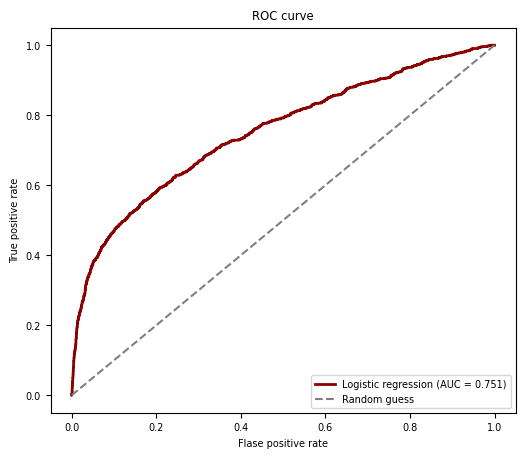

In [ ]:
# ROC CURVE + AUC (use predicted PROBABILITIES)
probs = logreg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)
# plot the ROC curve, labelled with the AUC, plus the diagonal
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Logistic regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray',linestyle='--', label='Random guess')

plt.xlabel('Flase positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.show()

### <span style="color:#990000">Q10. About 12% of clients subscribe, so predicting “no” for everyone already scores ~88%. What did your lazy baseline get, how close is the model’s accuracy, and what does <b>AUC</b> capture that accuracy misses?</span>

Our lazy baseline got 88.30%, but the logistic regression model's accuracy was 88.40%. Accuracy is misleading because a completely useless model that just guesses "no" for everyone still scores an 88.30% while catching 0 subscribers. AUC evaluates how well the model ranks clienets by probability across all possible thresholds. Although the accuracy isn't much higher, the AUC score proves it is excellent at separating potential subscirbers from non-subscribers.

## 9) Campaign simulation: who should the bank call?

Turn the model into a decision. Rank the **test** clients by predicted probability, “call” the **top 20%**, and compare subscribers reached vs calling 20% **at random**.

In [ ]:
budget = 0.20   # the call centre can phone the top 20%

# 1. table of each test client's true label and predicted probability
df_sim = pd.DataFrame({"true_label":y_test, "prob":probs})
# 2. sort by probability (highest first) and take the top 20%
df_sim_sorted = df_sim.sort_values(by="prob", ascending=False)
num_to_call = int(len(df_sim_sorted) * budget)
top_20 = df_sim_sorted.head(num_to_call)
# 3. how many ACTUAL subscribers are in that top 20%?
actual_subs_model = top_20["true_label"].sum()
total_subs = df_sim["true_label"].sum()
# 4. how many subscribers would 20% AT RANDOM reach?
random_subs = total_subs*budget
# 5. print both and the lift (model / random)
lift = actual_subs_model / random_subs

print (
    f"Calling the top 20% the MODEL ranks highest reaches {actual_subs_model} of {total_subs} subscribers ({actual_subs_model/total_subs*100:.0f}% of them)."
)
print(f"Calling 20% at RANDOM would reach about {int(round(random_subs))}.")
print(f"Lift = {lift:.2f}x")

Calling the top 20% the MODEL ranks highest reaches 564 of 1058 subscribers (53% of them).
Calling 20% at RANDOM would reach about 212.
Lift = 2.67x


## 10) Recommendation to the bank (storytelling)

### <span style="color:#990000">Q11. In 3–5 sentences for a bank manager (no jargon): whom should the bank call first, and roughly how much better is your model than calling at random? Name one honest limitation.</span>

The bank should prioritize calling the top 20% of clients that our system flags as most likely to subscribe. By focusing our resources on this targeted group the model is 2.67 times more effective at finding actual subscribers compared to just calling random people. The one limitation is that human behavior and economic conditions change over time.

<div style="border-left:6px solid #4E3629;background:#F2EEE9;padding:14px 18px;border-radius:4px;font-family:Lato,Arial,sans-serif;"><b style="color:#4E3629;">Section 11 — Stretch goal (optional, leaderboard / bonus)</b> — the core deliverable is your logistic pipeline. If you finish early, train a Random Forest and compare its AUC. Skipping it costs nothing.</div>

Random forest accuracy: 0.8931


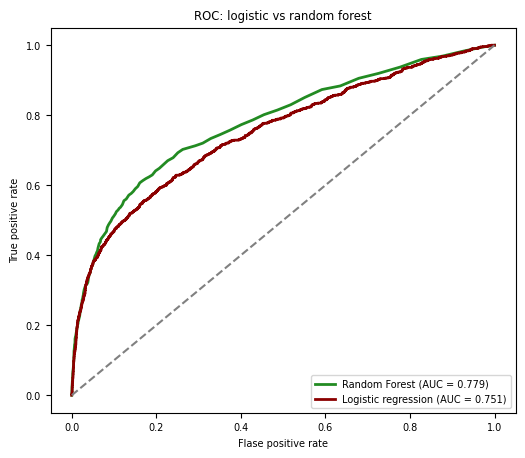

In [ ]:
# OPTIONAL — Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
# accuracy, then probabilities -> ROC + AUC, plotted against logistic
rf_preds = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)
print(f"Random forest accuracy: {rf_acc:.4f}")

rf_probs = rf. predict_proba(X_test_scaled)[:, 1]
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, rf_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(6, 5))

plt.plot(rf_fpr, rf_tpr, color='forestgreen', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'Logistic regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('Flase positive rate')
plt.ylabel('True positive rate')
plt.title('ROC: logistic vs random forest')
plt.legend(loc='lower right')
plt.show()

### <span style="color:#990000">Q12. (Optional) How did the Random Forest’s AUC compare? Which model would you ship to the bank, and why?</span>

Based on the graph, the random forest is slightly higher tow3ard the top-left corner than the logistic line. This means it has a higher AUC. However, although it has a higher AUC the logisitc regression is more interpretable, so it would be better to ship the logistic one to the bank.

## 12) Team retrospective

### <span style="color:#990000">Q13. What broke in your collaboration — a merge conflict, a missed meeting across time zones, a version mismatch, uneven workload — and how did you fix it? What will you do differently next time?</span>


> One problem we had in our collaboration is working across different time zones. With that being said, we still managed to set up two meetings in order to get our work and responsibilities organized. We did manage to split the workload pretty evenly. Some of us had been working on different versions, so it took a second to merge everything together at the end, but we did manage to do so. Next time, we would probably meet once or twice more, and also confirm which document we would work on and rename it so that we knew to add our final code and answers to that document.




## Deliverables & submission

- Submit the completed **`.ipynb`**, named with your team number, via **GitHub** (e.g. **`Team7_logistic_regression_1_3.ipynb`**).
- Include a **`ReadMe.txt`** with members’ names, your **team charter** (times *with time zones*, section owners), and a **contribution log** (each member: what they did + their commits).
- **Before submitting:** **Runtime → Restart and run all** so the notebook runs top-to-bottom with no errors.
- Give repo access to **`gk2311`** on GitHub and paste the link in the Canvas submission.

<div style="font-size:12px;color:#8A7F75;font-family:Lato,Arial,sans-serif;">Dataset: S. Moro, R. Laureano and P. Cortez (2011). <i>Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology.</i> In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference — ESM’2011, pp. 117–121, Guimarães, Portugal, October 2011. EUROSIS. Available: http://hdl.handle.net/1822/14838</div>